# Solar Power Generation Prediction

## Author: Zichen Hu(zih050@ucsd.edu) [Team 15]

This notebook is a walkthrough of our coding parts for the project, each step is explained thoroughly and is consistent with our report. We will also reuse some of the plots in our final presentation slides.

This notebook has these following parts:
1. EDA and data preprocessing
2. Baseline Models
3. Nonlinear Machine Learning Models
4. Model Comparison
5. Feature Importance and Interpretation
6. Error Analysis
7. Simple Solar Generation Prediction System

# Part 1: EDA and Data Preprocessing

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

solar = pd.read_csv("solar.csv")

print("Dataset shape:", solar.shape)
print("\nColumns:")
for col in solar.columns:
    print(col)
print("\nMissing values:")
print(solar.isna().sum())
print("\nDataset information:")
solar.info()

Dataset shape: (4213, 21)

Columns:
temperature_2_m_above_gnd
relative_humidity_2_m_above_gnd
mean_sea_level_pressure_MSL
total_precipitation_sfc
snowfall_amount_sfc
total_cloud_cover_sfc
high_cloud_cover_high_cld_lay
medium_cloud_cover_mid_cld_lay
low_cloud_cover_low_cld_lay
shortwave_radiation_backwards_sfc
wind_speed_10_m_above_gnd
wind_direction_10_m_above_gnd
wind_speed_80_m_above_gnd
wind_direction_80_m_above_gnd
wind_speed_900_mb
wind_direction_900_mb
wind_gust_10_m_above_gnd
angle_of_incidence
zenith
azimuth
generated_power_kw

Missing values:
temperature_2_m_above_gnd            0
relative_humidity_2_m_above_gnd      0
mean_sea_level_pressure_MSL          0
total_precipitation_sfc              0
snowfall_amount_sfc                  0
total_cloud_cover_sfc                0
high_cloud_cover_high_cld_lay        0
medium_cloud_cover_mid_cld_lay       0
low_cloud_cover_low_cld_lay          0
shortwave_radiation_backwards_sfc    0
wind_speed_10_m_above_gnd            0
wind_directio

We first load the solar power generation dataset and check its basic structure. The dataset contains meteorological variables, cloud-cover measurements, wind variables, solar-position features, and the target variable `generated_power_kw`. Since our goal is to predict a continuous power value, we treat this project as a supervised regression problem.

We also check the column names, data types, and missing values. The dataset has 4213 observations and 21 columns. Since there are no missing values, no imputation step is needed before modeling.

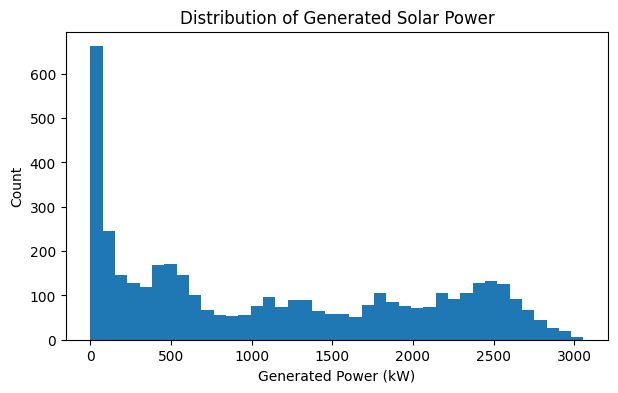

count    4213.000000
mean     1134.347313
std       937.957247
min         0.000595
25%       231.700450
50%       971.642650
75%      2020.966700
max      3056.794100
Name: generated_power_kw, dtype: float64


In [4]:
target = "generated_power_kw"

plt.figure(figsize=(7, 4))
plt.hist(solar[target], bins=40)
plt.xlabel("Generated Power (kW)")
plt.ylabel("Count")
plt.title("Distribution of Generated Solar Power")
plt.show()

print(solar[target].describe())

We compute summary statistics for for the target variable and visualize its distribution. The target variable `generated_power_kw` is continuous and nonnegative. Its distribution includes both low-generation and high-generation cases, which means the models need to learn solar output under different environmental conditions.

Thermodynamic
['temperature_2_m_above_gnd', 'relative_humidity_2_m_above_gnd', 'mean_sea_level_pressure_MSL']

Precipitation
['total_precipitation_sfc', 'snowfall_amount_sfc']

Cloud cover
['total_cloud_cover_sfc', 'high_cloud_cover_high_cld_lay', 'medium_cloud_cover_mid_cld_lay', 'low_cloud_cover_low_cld_lay']

Radiation
['shortwave_radiation_backwards_sfc']

Wind
['wind_speed_10_m_above_gnd', 'wind_direction_10_m_above_gnd', 'wind_speed_80_m_above_gnd', 'wind_direction_80_m_above_gnd', 'wind_speed_900_mb', 'wind_direction_900_mb', 'wind_gust_10_m_above_gnd']

Solar geometry
['angle_of_incidence', 'zenith', 'azimuth']



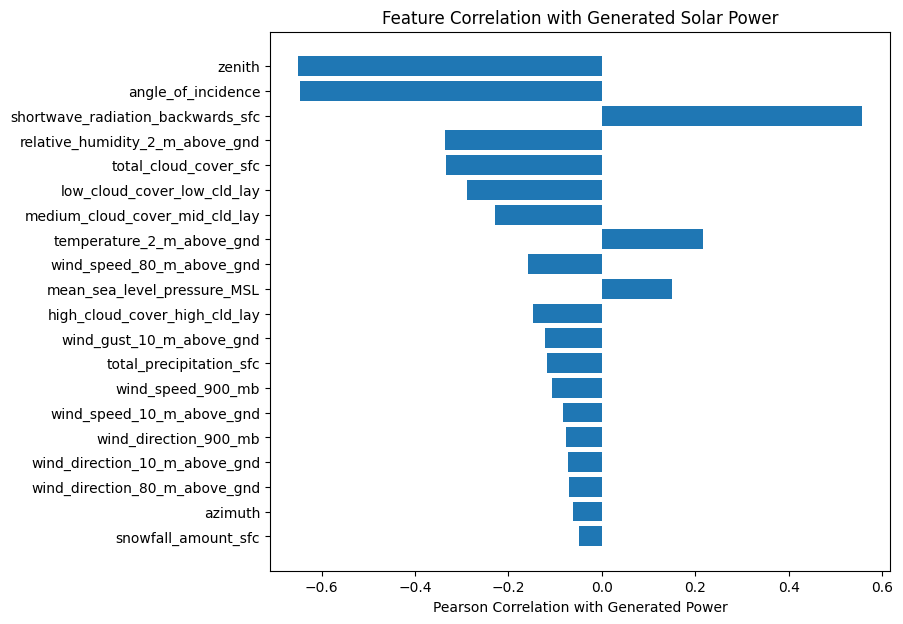

zenith                              -0.649991
angle_of_incidence                  -0.646537
shortwave_radiation_backwards_sfc    0.556148
relative_humidity_2_m_above_gnd     -0.336783
total_cloud_cover_sfc               -0.334338
low_cloud_cover_low_cld_lay         -0.288066
medium_cloud_cover_mid_cld_lay      -0.227834
temperature_2_m_above_gnd            0.217280
wind_speed_80_m_above_gnd           -0.157899
mean_sea_level_pressure_MSL          0.150551
high_cloud_cover_high_cld_lay       -0.147723
wind_gust_10_m_above_gnd            -0.122808
total_precipitation_sfc             -0.118442
wind_speed_900_mb                   -0.107615
wind_speed_10_m_above_gnd           -0.083043
wind_direction_900_mb               -0.077435
wind_direction_10_m_above_gnd       -0.073257
wind_direction_80_m_above_gnd       -0.069941
azimuth                             -0.061184
snowfall_amount_sfc                 -0.049508
Name: generated_power_kw, dtype: float64

In [5]:
feature_groups = {
    "Thermodynamic": [
        "temperature_2_m_above_gnd",
        "relative_humidity_2_m_above_gnd",
        "mean_sea_level_pressure_MSL"
    ],
    "Precipitation": [
        "total_precipitation_sfc",
        "snowfall_amount_sfc"
    ],
    "Cloud cover": [
        "total_cloud_cover_sfc",
        "high_cloud_cover_high_cld_lay",
        "medium_cloud_cover_mid_cld_lay",
        "low_cloud_cover_low_cld_lay"
    ],
    "Radiation": [
        "shortwave_radiation_backwards_sfc"
    ],
    "Wind": [
        "wind_speed_10_m_above_gnd",
        "wind_direction_10_m_above_gnd",
        "wind_speed_80_m_above_gnd",
        "wind_direction_80_m_above_gnd",
        "wind_speed_900_mb",
        "wind_direction_900_mb",
        "wind_gust_10_m_above_gnd"
    ],
    "Solar geometry": [
        "angle_of_incidence",
        "zenith",
        "azimuth"
    ]
}

for group, cols in feature_groups.items():
    print(group)
    print(cols)
    print()

corr_with_target = solar.corr(numeric_only=True)[target].drop(target)
corr_with_target = corr_with_target.sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 7))
plt.barh(corr_with_target.index[::-1], corr_with_target.values[::-1])
plt.xlabel("Pearson Correlation with Generated Power")
plt.title("Feature Correlation with Generated Solar Power")
plt.show()

display(corr_with_target)

To make the variables easier to interpret, we organize the features into physical groups: thermodynamic variables, precipitation variables, cloud-cover variables, radiation, wind variables, and solar-geometry variables. This helps connect the machine learning results with physical intuition.

We then compute the Pearson correlation between each feature and the target variable. Pearson correlation is calculated as:

$$
r = \frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}
{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}}
$$

This gives a first look at which variables have stronger linear relationships with generated solar power. However, correlation only measures linear association, so nonlinear models and feature-importance methods are still needed later.

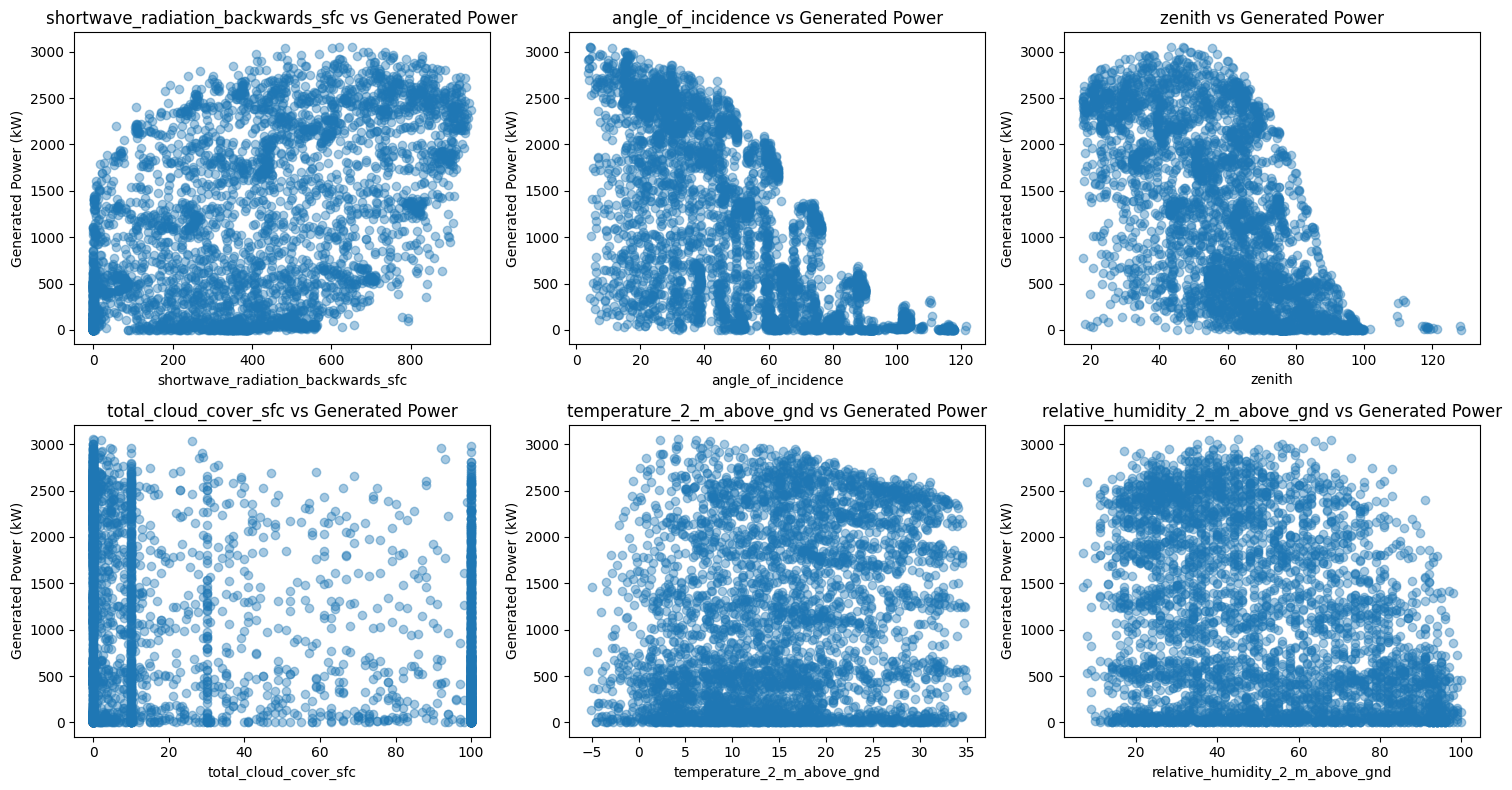

In [6]:
important_features = [
    "shortwave_radiation_backwards_sfc",
    "angle_of_incidence",
    "zenith",
    "total_cloud_cover_sfc",
    "temperature_2_m_above_gnd",
    "relative_humidity_2_m_above_gnd"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, col in enumerate(important_features):
    axes[i].scatter(solar[col], solar[target], alpha=0.4)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Generated Power (kW)")
    axes[i].set_title(f"{col} vs Generated Power")

plt.tight_layout()
plt.show()

We visualize several important physical variables against generated solar power. These plots help check whether the data follows basic physical expectations. For example, shortwave radiation should generally have a positive relationship with generated power while cloud cover may reduce the output.

These plots also show that the relationships are not always linear. This supports the use of nonlinear machine learning models such as random forest, gradient boosting, support vector regression, and neural networks.

In [7]:
solar_processed = solar.copy()

angle_cols = [
    "wind_direction_10_m_above_gnd",
    "wind_direction_80_m_above_gnd",
    "wind_direction_900_mb",
    "azimuth"
]

for col in angle_cols:
    radians = np.deg2rad(solar_processed[col])
    solar_processed[col + "_sin"] = np.sin(radians)
    solar_processed[col + "_cos"] = np.cos(radians)

solar_processed = solar_processed.drop(columns=angle_cols)

print("Original shape:", solar.shape)
print("Processed shape:", solar_processed.shape)

Original shape: (4213, 21)
Processed shape: (4213, 25)


Some variables are directional angles, such as wind direction and azimuth. Directly treating these values as ordinary numerical variables can be misleading because angles near $0^{\circ}$ and $360^{\circ}$ are physically close but numerically far apart. To avoid this issue, we encode each directional variable using sine and cosine transformations:

$$
\theta_{\sin} = \sin\left(\frac{\pi \theta}{180}\right)
$$

$$
\theta_{\cos} = \cos\left(\frac{\pi \theta}{180}\right)
$$

After this transformation, the original directional columns are removed and replaced by their sine and cosine components.

In [8]:
X = solar_processed.drop(columns=[target])
y = solar_processed[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=228
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Training set:", X_train.shape, y_train.shape)
print("Testing set:", X_test.shape, y_test.shape)

Feature matrix shape: (4213, 24)
Target vector shape: (4213,)
Training set: (3370, 24) (3370,)
Testing set: (843, 24) (843,)


After preprocessing, we separate the dataset into the feature matrix \(X\) and the target vector \(y\). The target variable is `generated_power_kw`, and all remaining processed columns are used as input features.

We split the data into training and testing sets using an 80/20 split with a fixed random seed for reproducibility. The training set is used to fit the models, while the testing set is held out for final evaluation.

We also standardize the input features for models that are sensitive to scale, such as linear regression, support vector regression, and neural networks. Standardization is computed as:

$$
z = \frac{x - \mu}{\sigma}
$$

where $\mu$ is the mean and $\sigma$ is the standard deviation of the training feature. The scaler is fitted only on the training set, then applied to both the training and testing sets to avoid data leakage.

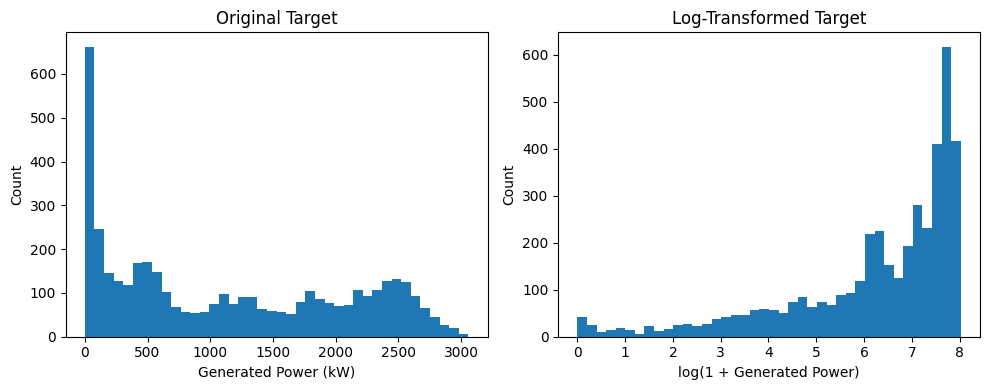

In [9]:
y_log = np.log1p(y)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(y, bins=40)
plt.xlabel("Generated Power (kW)")
plt.ylabel("Count")
plt.title("Original Target")

plt.subplot(1, 2, 2)
plt.hist(y_log, bins=40)
plt.xlabel("log(1 + Generated Power)")
plt.ylabel("Count")
plt.title("Log-Transformed Target")

plt.tight_layout()
plt.show()

We also check a log transformation of the target variable. Since solar power generation is nonnegative and has a wide range of values, a log transformation may make the target distribution less skewed.

The transformation is:

$$
y_{\log} = \log(1+y)
$$

If we train a model using the log-transformed target, the predictions can be converted back to the original kW scale using:

$$
\hat{y} = \exp(\hat{y}_{\log}) - 1
$$

In this project, we treat this part as optional. We will first train baseline models using original target values, and later we can compare whether the log-transformed target improves prediction performance.

# Part 2: Baseline Models
- Linear regression
- Ridge regression
- LASSO regression

In [10]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

We first train simple baseline regression models before more complex nonlinear methods. These models help us understand the minimum level of performance that later models should improve on.

The models are evaluated using three regression metrics: mean absolute error, root mean squared error, and $R^{2}$. 

MAE measures the average absolute prediction error in kW:

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
$$

RMSE gives a larger penalty to large prediction errors:

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
$$

The $R^{2}$ score measures how much variance is explained by the model compared with predicting the mean:

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}{\sum_{i=1}^{n}(y_i-\bar{y})^2}
$$

In [11]:
baseline_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=1.0, max_iter=10000)
}

baseline_results = []

for name, model in baseline_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    baseline_results.append(evaluate_model(name, y_test, y_pred))

baseline_results = pd.DataFrame(baseline_results)
display(baseline_results)

,Model,MAE,RMSE,R2
0,Linear Regression,373.570183,501.102925,0.706488
1,Ridge Regression,373.510424,501.021325,0.706583
2,Lasso Regression,373.369105,500.896789,0.706729


We train three baseline models: linear regression, ridge regression, and lasso regression. Linear regression fits a direct linear relationship between the input features and generated power. Ridge regression adds an \(L_2\) penalty to reduce overfitting, while lasso regression adds an \(L_1\) penalty that can shrink some coefficients toward zero.

The ridge objective is:

$$
\min_{\beta} \sum_{i=1}^{n}(y_i-\hat{y}_i)^2 + \lambda \sum_{j=1}^{p}\beta_j^2
$$

The lasso objective is:

$$
\min_{\beta} \sum_{i=1}^{n}(y_i-\hat{y}_i)^2 + \lambda \sum_{j=1}^{p}|\beta_j|
$$

From the baseline results, all three linear models give very similar performance. Lasso regression performs slightly better, with the lowest MAE and RMSE and the highest $R^{2}$. However, the improvement over ordinary linear regression and ridge regression is very small. This suggests that regularization does not greatly change the performance for these baseline linear models. Still, we treat the best baseline model which is Lasso Regression, with an RMSE of about 500.90 kW and an $R^{2}$ value of about 0.707. This means the linear baseline can explain around 70.7% of the variation in generated solar power, but there is still a noticeable amount of prediction error left for nonlinear models to improve on.

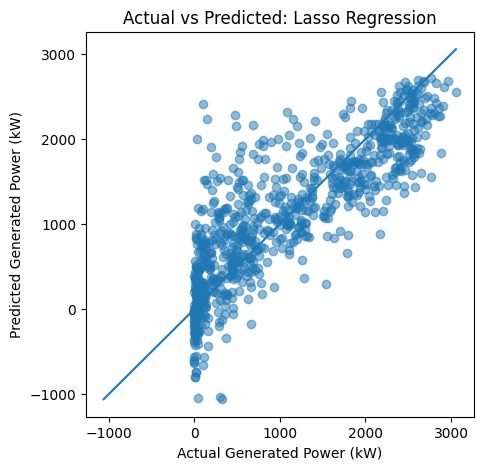

,Feature,Coefficient,Abs_Coefficient
14,angle_of_incidence,-440.246421,440.246421
22,azimuth_sin,415.785988,415.785988
9,shortwave_radiation_backwards_sfc,400.674651,400.674651
15,zenith,-100.045614,100.045614
2,mean_sea_level_pressure_MSL,97.917084,97.917084
1,relative_humidity_2_m_above_gnd,-90.524659,90.524659
0,temperature_2_m_above_gnd,-85.404137,85.404137
12,wind_speed_900_mb,-80.602514,80.602514
5,total_cloud_cover_sfc,-68.476189,68.476189
23,azimuth_cos,58.971596,58.971596


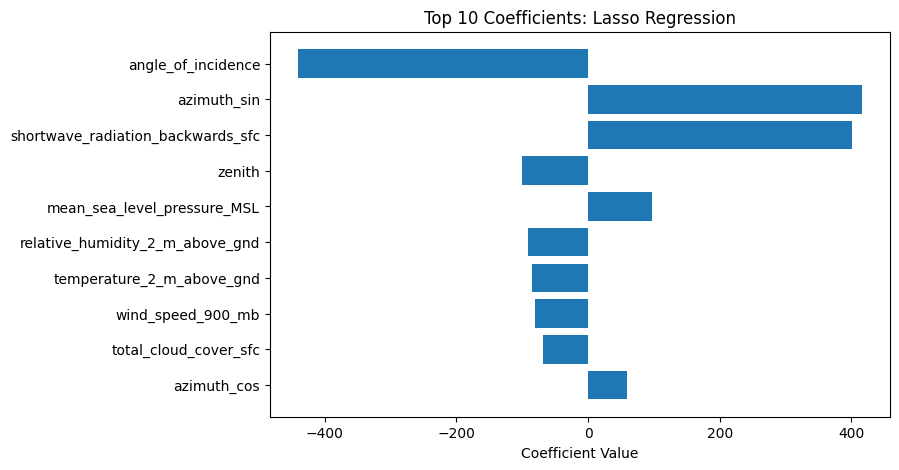

In [12]:
best_baseline_name = baseline_results.sort_values("RMSE").iloc[0]["Model"]
best_baseline_model = baseline_models[best_baseline_name]
best_baseline_pred = best_baseline_model.predict(X_test_scaled)

plt.figure(figsize=(5, 5))
plt.scatter(y_test, best_baseline_pred, alpha=0.5)
plt.xlabel("Actual Generated Power (kW)")
plt.ylabel("Predicted Generated Power (kW)")
plt.title(f"Actual vs Predicted: {best_baseline_name}")

min_val = min(y_test.min(), best_baseline_pred.min())
max_val = max(y_test.max(), best_baseline_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.show()

coef_df = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Coefficient": best_baseline_model.coef_
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Abs_Coefficient", ascending=False)

display(coef_df.head(10))

plt.figure(figsize=(8, 5))
plt.barh(coef_df.head(10)["Feature"][::-1], coef_df.head(10)["Coefficient"][::-1])
plt.xlabel("Coefficient Value")
plt.title(f"Top 10 Coefficients: {best_baseline_name}")
plt.show()

Using Lasso regression, we create some plots. The actual versus predicted plot compares the predicted generated power with the true generated power values. Points closer to the diagonal line indicate better prediction performance.

The plot shows that the baseline model captures the general trend of solar generation, but the predictions are still spread around the diagonal line. This means the linear model can learn some major relationships in the data, but it does not fully capture all nonlinear effects from weather, cloud cover, and solar geometry.

We also inspect the largest coefficients from the Lasso regression model. They include `angle_of_incidence`, `azimuth_sin` and `shortwave_radiation_backwards_sfc`. This agrees with the physical expectation that solar geometry and incoming radiation are important factors for solar power generation.

Some weather related variables, such as relative humidity, temperature and wind speed also appear in the top coefficients. However, we think more flexible nonlinear models may give a better understanding of feature importance later as the coefficient values are rather small in our current analysis.

# Part 3: Nonlinear Machine Learning Models
- SVR(Support vector regression)
- Random forest regression
- Gradient boosting regression
- Neural network regression

## 3.1 SVR

In [13]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

svr_param_grid = {
    "C": [1, 10, 100],
    "epsilon": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.1]
}

svr_grid = GridSearchCV(
    SVR(kernel="rbf"),
    svr_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

svr_grid.fit(X_train_scaled, y_train)
print("Best SVR parameters:")
print(svr_grid.best_params_)
best_svr = svr_grid.best_estimator_

Best SVR parameters:
{'C': 100, 'epsilon': 10, 'gamma': 'scale'}


After the baseline linear models, we first test Support Vector Regression (SVR). SVR is useful because it can model nonlinear relationships between the input features and generated solar power. This is important for solar prediction because the effect different factors have are not purely linear. We use the radial basis function (RBF) kernel because it is a common choice for nonlinear regression problems. The RBF kernel can be written as:

$$
K(x_i, x_j) = \exp(-\gamma ||x_i - x_j||^2)
$$

We tune three important hyperparameters: $C$, $\epsilon$, and $\gamma$. The parameter $C$ controls the penalty for prediction errors, $\epsilon$ controls the width of the insensitive tube around the prediction function, and $\gamma$ controls the influence range of each training point. The best parameters selected by cross validation are $C=100$, $\epsilon=10$ and $\gamma=\text{scale}$. Since SVR is sensitive to feature scale, we train it using the standardized feature matrices.

In [14]:
svr_pred = best_svr.predict(X_test_scaled)
svr_result = evaluate_model("SVR", y_test, svr_pred)
svr_result = pd.DataFrame([svr_result])
display(svr_result)

,Model,MAE,RMSE,R2
0,SVR,297.041376,451.396966,0.761829


We evaluate the best SVR model on the testing set using MAE, RMSE, and $R^{2}$. The SVR model achieves MAE of about 297.04 kW, RMSE of about 451.4 kW, and $R^2$ value of about 0.762. Compared with the best linear baseline model, SVR reduces both MAE and RMSE and increases $R^2$ from about 0.707 to about 0.762. This suggests that the nonlinear RBF kernel captures part of the relationship between environmental features and generated solar power better than the linear models.

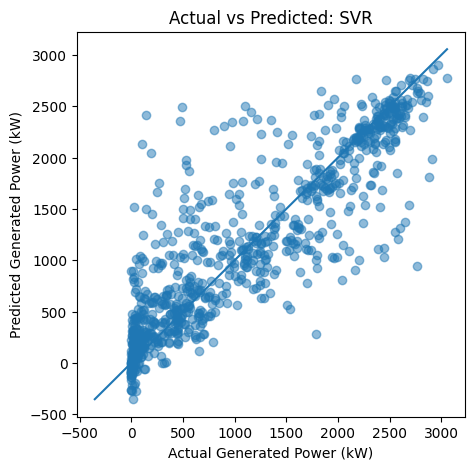

In [15]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, svr_pred, alpha=0.5)
plt.xlabel("Actual Generated Power (kW)")
plt.ylabel("Predicted Generated Power (kW)")
plt.title("Actual vs Predicted: SVR")

min_val = min(y_test.min(), svr_pred.min())
max_val = max(y_test.max(), svr_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.show()

The actual versus predicted plot shows how close the SVR predictions are to the true generated power values. The points generally follow the diagonal trend, which means the model captures the overall relationship between the input features and solar generation. However, the points are still spread around the diagonal line, especially for some medium and high generation values. This means that SVR improves over the linear baseline models, but it still does not fully explain all variation in solar output. This leaves room for tree-based ensemble models such as random forest and gradient boosting to possibly improve performance.

## 3.2 Random Forest Regression

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=228),
    rf_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
print("Best Random Forest parameters:")
print(rf_grid.best_params_)
best_rf = rf_grid.best_estimator_

Best Random Forest parameters:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


Next, we train a Random Forest regression model. Compared with linear regression, Random Forest can capture nonlinear relationships and interactions between features without requiring us to manually specify those relationships. For regression, the prediction can be viewed as the average prediction across many trees:

$$
\hat{y} = \frac{1}{B}\sum_{b=1}^{B} T_b(x)
$$

where $B$ is the number of trees and $T_{b(x)}$ is the prediction from the $b$-th decision tree. We tune several important parameters, including the number of trees, maximum tree depth, minimum samples required to split a node, and minimum samples required at a leaf node. The best model selected by cross validation uses 200 trees, a maximum depth of 20, a minimum of 2 samples to split a node, and a minimum of 2 samples per leaf. Since tree-based models are not very sensitive to feature scaling, we train Random Forest using the unscaled feature matrix.

In [17]:
rf_pred = best_rf.predict(X_test)
rf_result = evaluate_model("Random Forest", y_test, rf_pred)
rf_result = pd.DataFrame([rf_result])
display(rf_result)

,Model,MAE,RMSE,R2
0,Random Forest,248.771785,394.342027,0.818232


We evaluate the best Random Forest model on the testing set agian using MAE, RMSE, and $R^{2}$. The output is a noticeable improvement over the previous models. Compared with previous models, the RMSE has a significant decreasing trend. This suggests that tree-based nonlinear feature interactions are useful for predicting solar power generation from the environmental factors.

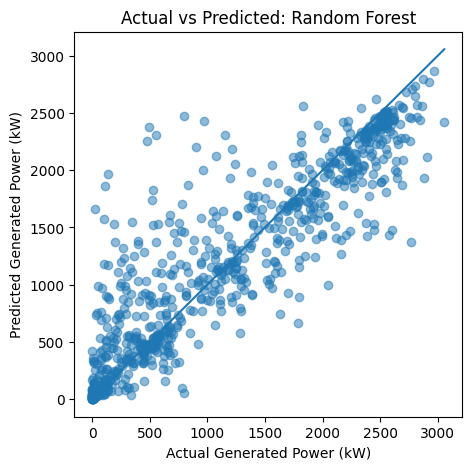

,Feature,Importance
14,angle_of_incidence,0.395209
5,total_cloud_cover_sfc,0.141700
15,zenith,0.117732
22,azimuth_sin,0.091978
9,shortwave_radiation_backwards_sfc,0.070980
1,relative_humidity_2_m_above_gnd,0.029024
2,mean_sea_level_pressure_MSL,0.020945
13,wind_gust_10_m_above_gnd,0.018407
0,temperature_2_m_above_gnd,0.016762
23,azimuth_cos,0.011243


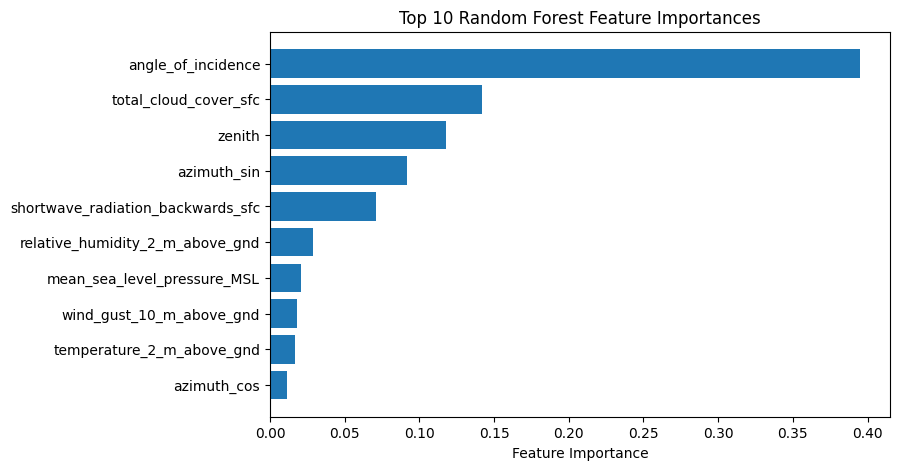

In [18]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, rf_pred, alpha=0.5)
plt.xlabel("Actual Generated Power (kW)")
plt.ylabel("Predicted Generated Power (kW)")
plt.title("Actual vs Predicted: Random Forest")

min_val = min(y_test.min(), rf_pred.min())
max_val = max(y_test.max(), rf_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.show()

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})
rf_importance = rf_importance.sort_values("Importance", ascending=False)
display(rf_importance.head(10))

plt.figure(figsize=(8, 5))
plt.barh(rf_importance.head(10)["Feature"][::-1], rf_importance.head(10)["Importance"][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 10 Random Forest Feature Importances")
plt.show()

The actual versus predicted plot shows that the Random Forest predictions follow the diagonal trend more closely than the previous baseline models. This means the model captures the general relationship between environmental features and generated solar power reasonably well. There are still some prediction errors, but the overall fit is stronger than the linear models and SVR.

The feature importance results show that `angle_of_incidence` is the most important feature in the Random Forest model, followed by `total_cloud_cover_sfc` and `zenith`. This result is physically reasonable because solar geometry and incoming radiation directly affect how much sunlight reaches the panel surface, while cloud cover can block or reduce sunlight.

Some additional variables also appear in the top ten features, but their importance values are much smaller. This suggests that they may provide secondary information, while solar geometry, radiation, and cloud cover are the main drivers of prediction performance. However, tree-based feature importance should still be interpreted carefully. It gives a useful first view of important variables, but later we can also use permutation importance to check whether the model truly depends on those features.

## 3.3 Gradient Boosting Regression

In [19]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

gbr_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0]
}

gbr_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=228),
    gbr_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

gbr_grid.fit(X_train, y_train)
print("Best Gradient Boosting parameters:")
print(gbr_grid.best_params_)
best_gbr = gbr_grid.best_estimator_

Best Gradient Boosting parameters:
{'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}


Next, we train a Gradient Boosting regression model. Instead of training many trees independently, it builds trees sequentially. Each new tree tries to correct the errors made by the previous trees. The prediction can be written as:

$$
\hat{y}(x) = \sum_{m=1}^{M} \eta f_m(x)
$$

where $M$ is the number of boosting stages, $f_m(x)$ is the prediction from the $m$-th tree, and $\eta$ is the learning rate. We tune the number of estimators, learning rate, maximum tree depth, and subsampling rate. The best model selected by cross validation uses 300 estimators, a learning rate of 0.05, maximum depth of 4, and subsample rate of 0.8. Since Gradient Boosting is a tree-based model, we train it using the unscaled feature matrix.

In [20]:
gbr_pred = best_gbr.predict(X_test)
gbr_result = evaluate_model("Gradient Boosting", y_test, gbr_pred)
gbr_result = pd.DataFrame([gbr_result])
display(gbr_result)

,Model,MAE,RMSE,R2
0,Gradient Boosting,256.55823,387.056807,0.824886


We evaluate the best Gradient Boosting model on the testing set using MAE, RMSE, and $R^{2}$. Compared with the previous models, Gradient Boosting gives the best RMSE and $R^{2}$ so far. Its RMSE is lower than the linear baseline, SVR, and Random Forest models. This suggests that the sequential boosting structure is useful for capturing nonlinear relationships between environmental features and solar power generation. However, Random Forest still has a slightly lower MAE than Gradient Boosting. This means Gradient Boosting reduces larger errors better overall, while Random Forest may have slightly smaller average absolute error.

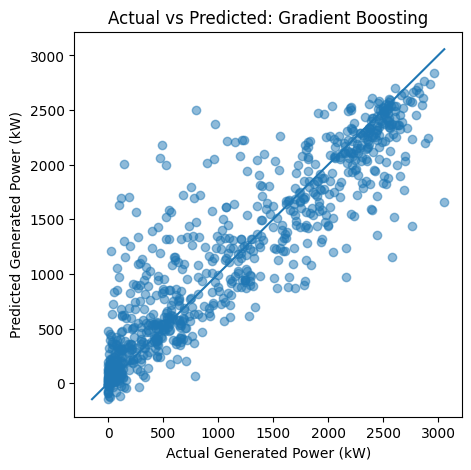

,Feature,Importance
14,angle_of_incidence,0.360267
15,zenith,0.174727
5,total_cloud_cover_sfc,0.135733
22,azimuth_sin,0.101151
9,shortwave_radiation_backwards_sfc,0.060773
1,relative_humidity_2_m_above_gnd,0.026529
2,mean_sea_level_pressure_MSL,0.023554
0,temperature_2_m_above_gnd,0.014328
23,azimuth_cos,0.013184
13,wind_gust_10_m_above_gnd,0.012793


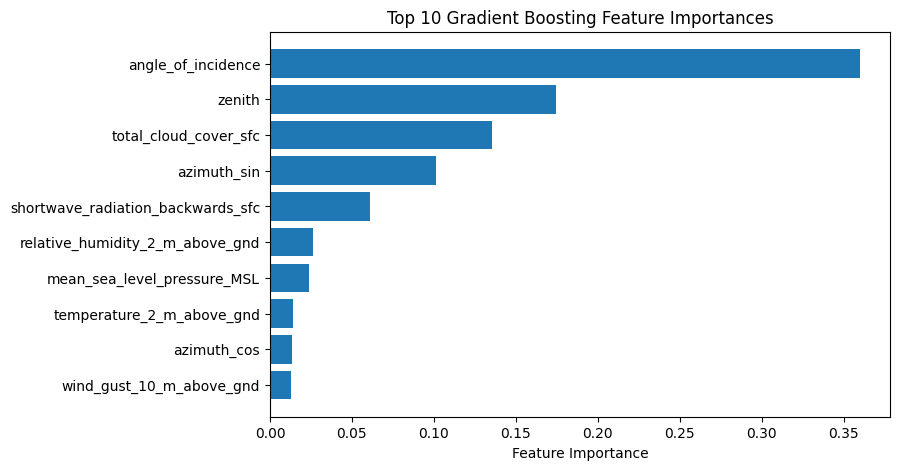

In [21]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, gbr_pred, alpha=0.5)
plt.xlabel("Actual Generated Power (kW)")
plt.ylabel("Predicted Generated Power (kW)")
plt.title("Actual vs Predicted: Gradient Boosting")

min_val = min(y_test.min(), gbr_pred.min())
max_val = max(y_test.max(), gbr_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.show()

gbr_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_gbr.feature_importances_
})
gbr_importance = gbr_importance.sort_values("Importance", ascending=False)
display(gbr_importance.head(10))

plt.figure(figsize=(8, 5))
plt.barh(gbr_importance.head(10)["Feature"][::-1], gbr_importance.head(10)["Importance"][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 10 Gradient Boosting Feature Importances")
plt.show()

The actual versus predicted plot shows that the Gradient Boosting predictions follow the diagonal trend closely. This is consistent with its strong RMSE and $R^{2}$ values. There are still some errors but the model captures the overall relationship between the input features and generated solar power better than the earlier models.

The top features are similar to the Random Forest results, which makes the interpretation more reliable. Solar geometry, cloud cover, and radiation appear to be the main drivers of solar power prediction, while other meteorological variables provide secondary information.

## 3.4 Neural Network Regression

In [22]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
import warnings

warnings.filterwarnings("ignore")

nn_param_grid = {
    "hidden_layer_sizes": [(32,), (64,), (64, 32)],
    "alpha": [0.0001, 0.001],
    "learning_rate_init": [0.001, 0.0005]
}

nn_grid = GridSearchCV(
    MLPRegressor(
        activation="relu",
        solver="adam",
        early_stopping=True,
        max_iter=2000,
        random_state=228
    ),
    nn_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1
)

nn_grid.fit(X_train_scaled, y_train)
print("Best Neural Network parameters:")
print(nn_grid.best_params_)
best_nn = nn_grid.best_estimator_

Best Neural Network parameters:
{'alpha': 0.0001, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001}


Finally, we train a neural network regression model using a multilayer perceptron. It is useful because solar generation depends on multiple interacting factors, such as radiation, cloud cover, temperature and solar geometry. A simple neural network layer can be written as:

$$
h = \sigma(Wx + b)
$$

where $x$ is the input feature vector, $W$ is the weight matrix, $b$ is the bias term, and $\sigma$ is the activation function. We use ReLU activation and the Adam optimizer. We also use early stopping to reduce overfitting. Since neural networks are sensitive to feature scale, this model is trained using the standardized feature matrices. The best neural network selected by cross validation uses two hidden layers with sizes 64 and 32, an alpha value of 0.0001 and an initial learning rate of 0.001.

In [23]:
nn_pred = best_nn.predict(X_test_scaled)
nn_result = evaluate_model("Neural Network", y_test, nn_pred)
nn_result = pd.DataFrame([nn_result])
display(nn_result)

,Model,MAE,RMSE,R2
0,Neural Network,291.897499,424.809961,0.789059


We evaluate the neural network model on the testing set using MAE, RMSE, and $R^2$. The result is better than the linear baseline models and SVR, which shows that the neural network can learn useful nonlinear relationships in the data. However, it does not outperform the tree-based ensemble models. Random Forest and Gradient Boosting both achieve lower RMSE and higher $R^2$ values. This is reasonable because the dataset is a structured tabular dataset with a moderate number of observations. Tree-based ensemble models often work very well on tabular data because they can capture nonlinear feature interactions without requiring as much data or tuning as neural networks. In this case, the neural network is useful as a nonlinear comparison model, but Gradient Boosting remains our strongest model so far.

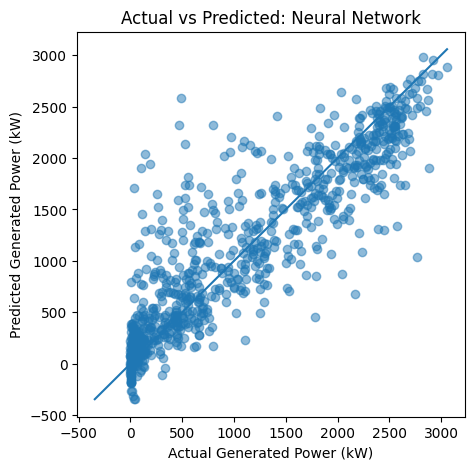

In [24]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, nn_pred, alpha=0.5)
plt.xlabel("Actual Generated Power (kW)")
plt.ylabel("Predicted Generated Power (kW)")
plt.title("Actual vs Predicted: Neural Network")

min_val = min(y_test.min(), nn_pred.min())
max_val = max(y_test.max(), nn_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.show()

The actual versus predicted plot shows that the neural network captures the general trend of generated solar power, but the points are still more spread out than the best tree-based models. The model performs reasonably well overall, but it still has noticeable errors for some medium and high generation values.

This result shows that a more flexible model is not always the best choice. Although neural networks are powerful, they may need more data and tuning to outperform Random Forest and Gradient Boosting on this dataset. For the current project, the neural network provides a useful nonlinear baseline, while the tree-based models appear more suitable for final prediction and interpretation.

# Part 4: Model Comparison

In [25]:
all_results = pd.concat(
    [
        baseline_results,
        svr_result,
        rf_result,
        gbr_result,
        nn_result
    ],
    ignore_index=True
)

all_results = all_results.sort_values("RMSE").reset_index(drop=True)
display(all_results)

,Model,MAE,RMSE,R2
0,Gradient Boosting,256.558230,387.056807,0.824886
1,Random Forest,248.771785,394.342027,0.818232
2,Neural Network,291.897499,424.809961,0.789059
3,SVR,297.041376,451.396966,0.761829
4,Lasso Regression,373.369105,500.896789,0.706729
5,Ridge Regression,373.510424,501.021325,0.706583
6,Linear Regression,373.570183,501.102925,0.706488


After training all models, we combine the testing results into one table. This makes it easier to compare the models using MAE, RMSE, and $R^{2}$. The results show that the nonlinear models clearly improve over the linear baseline models. Among all tested models, Gradient Boosting has the lowest RMSE and the highest $R^{2}$. Random Forest is also very competitive and has the lowest MAE.

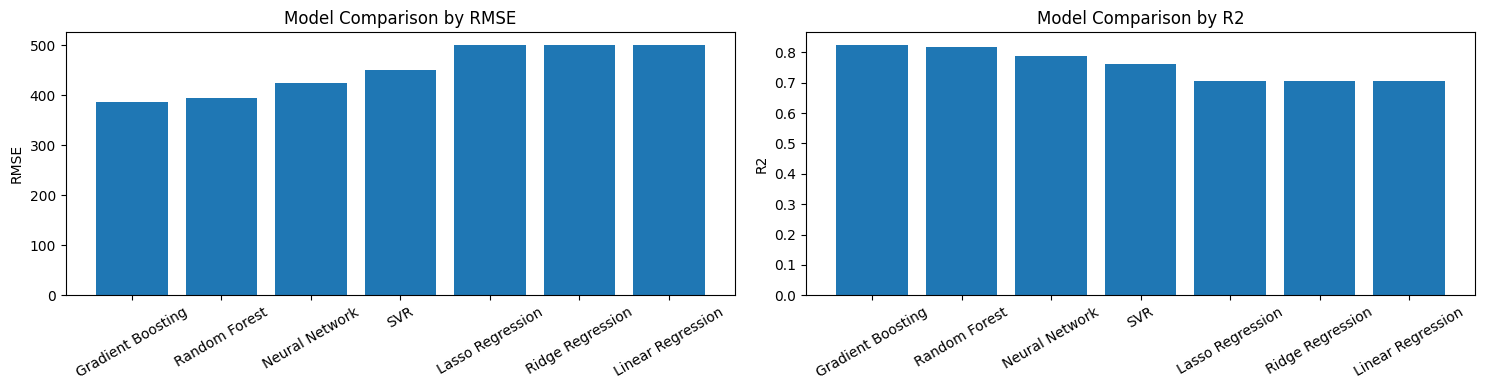

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].bar(all_results["Model"], all_results["RMSE"])
axes[0].set_ylabel("RMSE")
axes[0].set_title("Model Comparison by RMSE")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(all_results["Model"], all_results["R2"])
axes[1].set_ylabel("R2")
axes[1].set_title("Model Comparison by R2")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

The RMSE and $R^{2}$ plots give a direct visual comparison of model performance. The linear baseline models have the weakest performance, while the nonlinear models improve the prediction accuracy and the tree-based ensemble models perform the best overall.

In [27]:
best_model_row = all_results.iloc[0]
print("Best model based on RMSE:")
print(best_model_row)
best_model_name = best_model_row["Model"]

if best_model_name == "Gradient Boosting":
    final_model = best_gbr
    final_pred = gbr_pred
elif best_model_name == "Random Forest":
    final_model = best_rf
    final_pred = rf_pred
elif best_model_name == "SVR":
    final_model = best_svr
    final_pred = svr_pred
elif best_model_name == "Neural Network":
    final_model = best_nn
    final_pred = nn_pred
else:
    final_model = baseline_models[best_model_name]
    final_pred = final_model.predict(X_test_scaled)

print("\nFinal selected model:", best_model_name)

Best model based on RMSE:
Model    Gradient Boosting
MAE              256.55823
RMSE            387.056807
R2                0.824886
Name: 0, dtype: object

Final selected model: Gradient Boosting


Based on RMSE, we select the best model as the final prediction model. In this experiment, Gradient Boosting performs best overall. This result suggests that tree-based ensemble models are the most suitable models for this dataset. They can capture nonlinear relationships between solar geometry, cloud cover, radiation and generated power better than other models

# Part 5: Feature Importance and Interpretation
- Correlation analysis
- Model based feature importance
- SHAP

## 5.1 Correlation Analysis

In [28]:
pearson_corr = solar_processed.corr(method="pearson", numeric_only=True)[target].drop(target)
spearman_corr = solar_processed.corr(method="spearman", numeric_only=True)[target].drop(target)

corr_summary = pd.DataFrame({
    "Pearson": pearson_corr,
    "Spearman": spearman_corr
})

corr_summary["Abs_Pearson"] = corr_summary["Pearson"].abs()
corr_summary = corr_summary.sort_values("Abs_Pearson", ascending=False)
display(corr_summary.head(12))

,Pearson,Spearman,Abs_Pearson
zenith,-0.649991,-0.681905,0.649991
angle_of_incidence,-0.646537,-0.669280,0.646537
shortwave_radiation_backwards_sfc,0.556148,0.553944,0.556148
azimuth_cos,-0.540590,-0.555212,0.540590
relative_humidity_2_m_above_gnd,-0.336783,-0.302937,0.336783
total_cloud_cover_sfc,-0.334338,-0.311507,0.334338
low_cloud_cover_low_cld_lay,-0.288066,-0.266144,0.288066
medium_cloud_cover_mid_cld_lay,-0.227834,-0.221060,0.227834
temperature_2_m_above_gnd,0.217280,0.209958,0.217280
wind_speed_80_m_above_gnd,-0.157899,-0.140589,0.157899


After comparing the prediction models, we analyze which variables are most related to generated solar power. We first use correlation analysis because it gives a simple and interpretable view before using other methods. We compute both Pearson and Spearman correlations. Pearson correlation measures linear association:

$$
r = \frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}
{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}}
$$

Spearman correlation measures monotonic association based on ranked values. In the result table, `zenith` and `angle_of_incidence` have the strongest negative correlations with generated power. This is physically reasonable because larger zenith or incidence angle usually means less effective sunlight reaching the panel surface. `shortwave_radiation_backwards_sfc` has a strong positive correlation, which also matches the expectation that more incoming solar radiation leads to higher power generation.

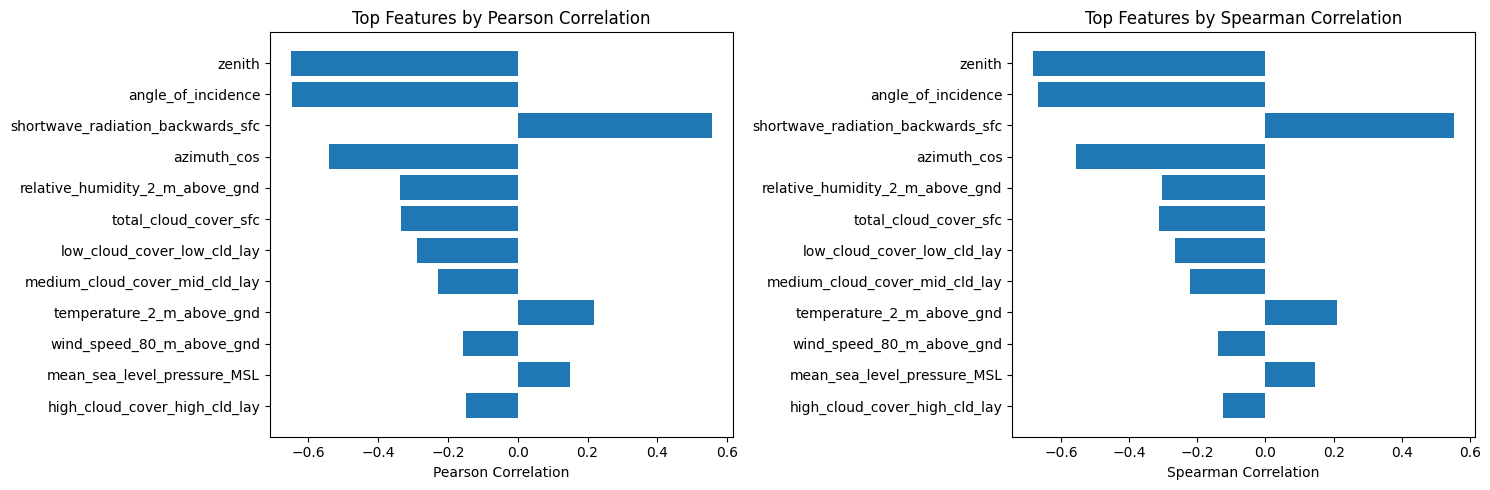

In [29]:
top_corr = corr_summary.head(12)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(top_corr.index[::-1], top_corr["Pearson"][::-1])
axes[0].set_xlabel("Pearson Correlation")
axes[0].set_title("Top Features by Pearson Correlation")

axes[1].barh(top_corr.index[::-1], top_corr["Spearman"][::-1])
axes[1].set_xlabel("Spearman Correlation")
axes[1].set_title("Top Features by Spearman Correlation")

plt.tight_layout()
plt.show()

The correlation plots show that solar position variables and radiation are the most strongly associated with generated power. Weather related variables also appear in the top features, but their correlations are weaker. Overall, the correlation results support the physical interpretation that solar generation is mainly driven by sun position and incoming radiation, with cloud cover and atmospheric conditions providing additional influence.

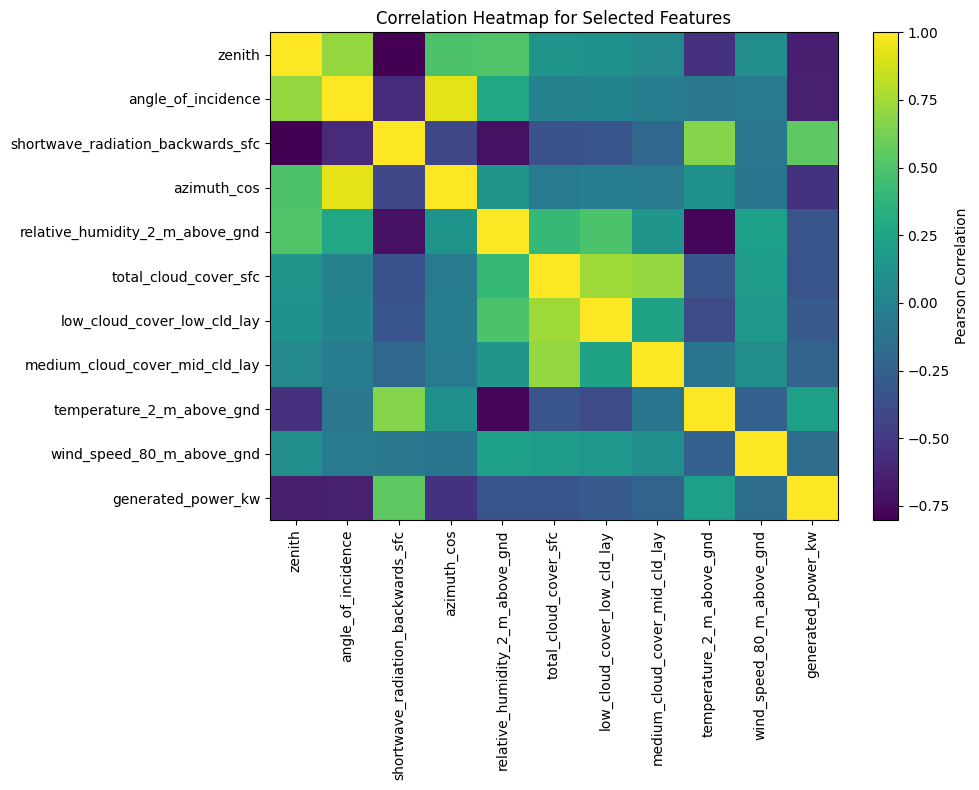

In [30]:
selected_corr_features = list(top_corr.index[:10]) + [target]
corr_matrix = solar_processed[selected_corr_features].corr(method="pearson")

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Pearson Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation Heatmap for Selected Features")
plt.tight_layout()
plt.show()

We also create a correlation heatmap for the most target related features. It helps us see that some important variables are also correlated with each other. For example, geometry variables such as `zenith`, `angle_of_incidence`, and `azimuth_cos` contain related information about the position of the sun. Cloud cover variables may also overlap because total cloud cover is connected to low, medium, and high cloud cover.

This means correlation analysis should not be used as the only feature importance method. A feature can have a strong individual correlation with the target, but the final model may rely on another related feature instead. Therefore, we will also use other ways to better understand which variables the trained models depend on.

## 5.2 Model Based Feature Importance

In [31]:
from sklearn.inspection import permutation_importance

gbr_builtin_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Built-in Importance": best_gbr.feature_importances_
})
gbr_builtin_importance = gbr_builtin_importance.sort_values(
    "Built-in Importance",
    ascending=False
)

perm_result = permutation_importance(
    best_gbr,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=10,
    random_state=228,
    n_jobs=-1
)

gbr_perm_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Permutation Importance": perm_result.importances_mean,
    "Permutation Std": perm_result.importances_std
})
gbr_perm_importance = gbr_perm_importance.sort_values(
    "Permutation Importance",
    ascending=False
)

importance_compare = gbr_builtin_importance.merge(
    gbr_perm_importance,
    on="Feature",
    how="inner"
)

importance_compare = importance_compare.sort_values(
    "Permutation Importance",
    ascending=False
)

display(importance_compare.head(12))

,Feature,Built-in Importance,Permutation Importance,Permutation Std
0,angle_of_incidence,0.360267,279.375431,12.332340
3,azimuth_sin,0.101151,195.508298,9.566753
1,zenith,0.174727,122.973868,6.790247
4,shortwave_radiation_backwards_sfc,0.060773,87.908192,5.879015
2,total_cloud_cover_sfc,0.135733,69.730928,2.657241
5,relative_humidity_2_m_above_gnd,0.026529,64.176141,7.682629
6,mean_sea_level_pressure_MSL,0.023554,36.601627,5.955580
9,wind_gust_10_m_above_gnd,0.012793,16.055699,1.970497
14,total_precipitation_sfc,0.006187,12.802479,2.234054
7,temperature_2_m_above_gnd,0.014328,11.967739,2.842675


After the correlation analysis, we use the final Gradient Boosting model to study feature importance. This gives a model based interpretation of which variables the trained model uses most for prediction. We combine two importance measures in one table: built-in Gradient Boosting importance and permutation importance. Built-in importance measures how much each feature helps reduce prediction error inside the boosted trees. Permutation importance measures how much the test RMSE increases when one feature is randomly shuffled while all other features are kept fixed.

The results show that `angle_of_incidence` is the most important feature under both methods. `azimuth_sin`, `zenith`, `shortwave_radiation_backwards_sfc` and `total_cloud_cover_sfc` are also highly important. This is consistent with the previous results.

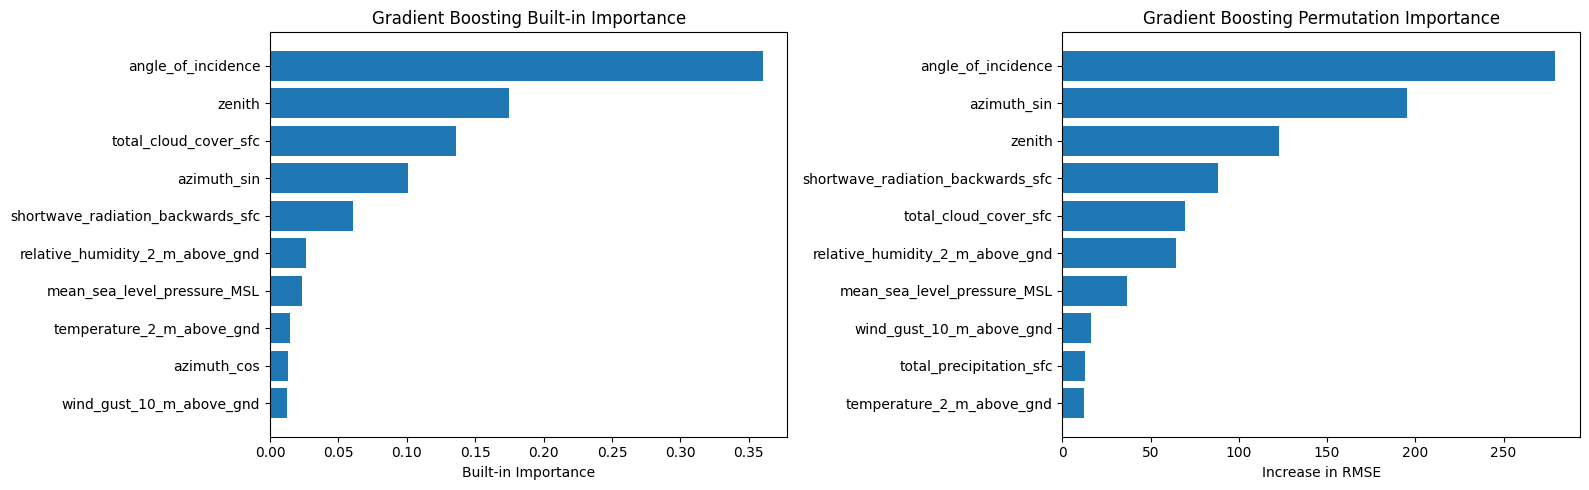

In [32]:
top_builtin = gbr_builtin_importance.head(10)
top_perm = gbr_perm_importance.head(10)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(
    top_builtin["Feature"][::-1],
    top_builtin["Built-in Importance"][::-1]
)
axes[0].set_xlabel("Built-in Importance")
axes[0].set_title("Gradient Boosting Built-in Importance")

axes[1].barh(
    top_perm["Feature"][::-1],
    top_perm["Permutation Importance"][::-1]
)
axes[1].set_xlabel("Increase in RMSE")
axes[1].set_title("Gradient Boosting Permutation Importance")

plt.tight_layout()
plt.show()

The two plots give similar main conclusions: `angle_of_incidence` is the strongest feature, and solar geometry variables remain near the top. However, there are some small differences between the two methods. For example, `zenith` has a larger built-in importance than `azimuth_sin`, while permutation importance ranks `azimuth_sin` higher than `zenith`. This can happen because built-in importance measures how often and how effectively a feature is used inside the trees, while permutation importance measures how much the final test error depends on that feature. Overall, the feature importance results support the same interpretation as the correlation analysis. Solar geometry, radiation, and cloud cover are the main drivers of generated solar power.

## 5.3 SHAP

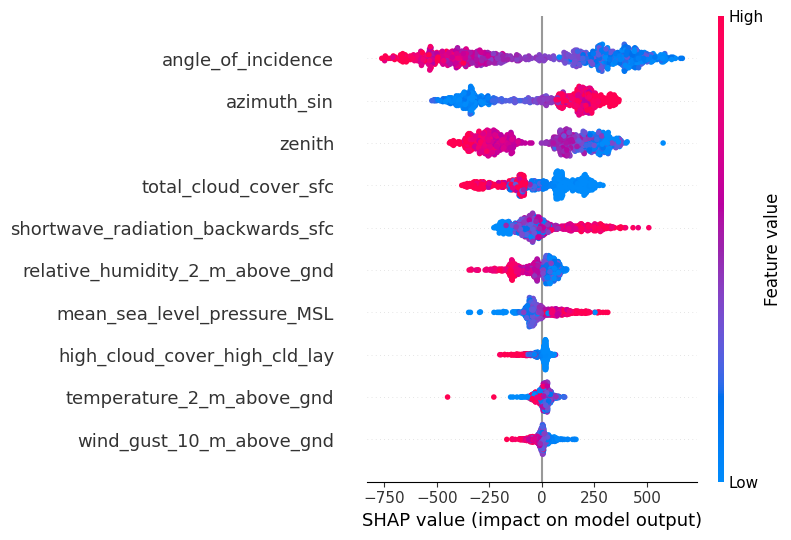

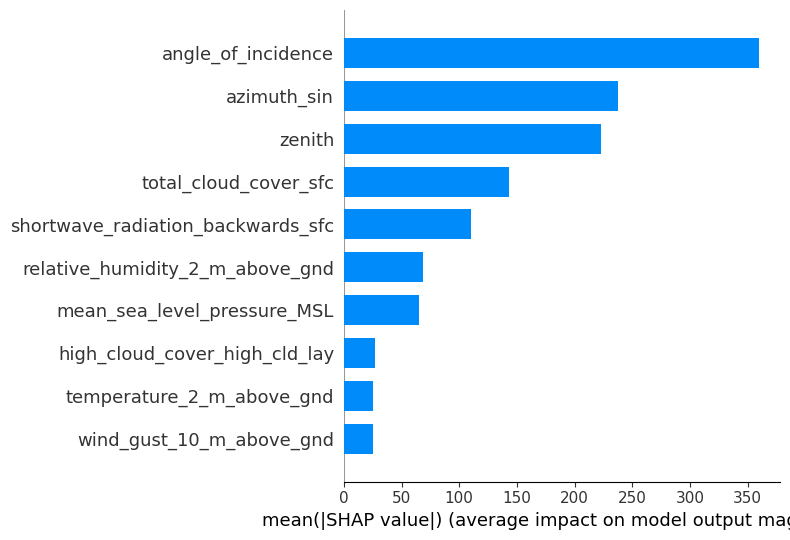

In [33]:
import shap
X_shap = X_test.copy()
explainer = shap.TreeExplainer(best_gbr)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=10
)

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    max_display=10
)

To further interpret the final Gradient Boosting model, we use SHAP values. SHAP explains how each feature contributes to a model prediction. Compared with built-in feature importance, SHAP gives both the magnitude and direction of each feature's effect. For one prediction, the SHAP explanation can be written as:

$$
f(x) = E[f(x)] + \sum_{j=1}^{p} \phi_j
$$

where $E[f(x)]$ is the average model prediction and $\phi_j$ is the contribution from feature $j$. A positive SHAP value increases the predicted solar power, while a negative SHAP value decreases the predicted solar power.

The plots provide another interpretation of the final Gradient Boosting model. The summary plot shows both feature importance and the direction of each feature's effect, while the bar plot ranks features by their average absolute SHAP value.

The most important SHAP features are consistent with the previous importance results. `angle_of_incidence` has the largest overall effect, followed by `azimuth_sin` and `zenith`. The summary plot also shows how feature values affect the prediction. For example, solar position features can either increase or decrease the predicted power depending on their values, while cloud cover generally has a negative effect when it represents less favorable sunlight conditions. These results support the physical interpretation that the model is not only fitting numerical patterns, but also learning relationships that are meaningful for solar power generation.

# Part 6: Error Analysis

In [48]:
error_df = X_test.copy()
error_df["actual_power"] = y_test
error_df["predicted_power"] = final_pred
error_df["error"] = error_df["predicted_power"] - error_df["actual_power"]
error_df["absolute_error"] = error_df["error"].abs()

display(error_df[["actual_power", "predicted_power", "error", "absolute_error"]].head())

print("Mean Error:", error_df["error"].mean())
print("Mean Absolute Error:", error_df["absolute_error"].mean())
print("Largest Absolute Error:", error_df["absolute_error"].max())

,actual_power,predicted_power,error,absolute_error
2770,2311.51950,2070.464539,-241.054961,241.054961
3758,2547.75440,2512.603091,-35.151309,35.151309
3621,685.95694,586.190157,-99.766783,99.766783
2053,916.91916,1164.466318,247.547158,247.547158
2939,1552.97840,1951.479826,398.501426,398.501426


Mean Error: 27.2069723771588
Mean Absolute Error: 256.55822996966447
Largest Absolute Error: 1860.2936153116168


After selecting Gradient Boosting as the final model, we analyze its prediction errors in more detail. For each testing sample, we compute the prediction error and absolute error

$$
e_i = \hat{y}_i - y_i
$$

$$
|e_i| = |\hat{y}_i - y_i|
$$

A positive error means the model overpredicts solar power, while a negative error means the model underpredicts solar power. The mean error is about 27.21 kW, which is close to zero compared with the scale of the target variable. This suggests that the model does not have a strong overall bias toward overprediction or underprediction. The mean absolute error is about 256.56 kW, which matches the MAE reported in the model comparison section. The largest absolute error is about 1860.29 kW, so a few individual cases are still difficult for the model.

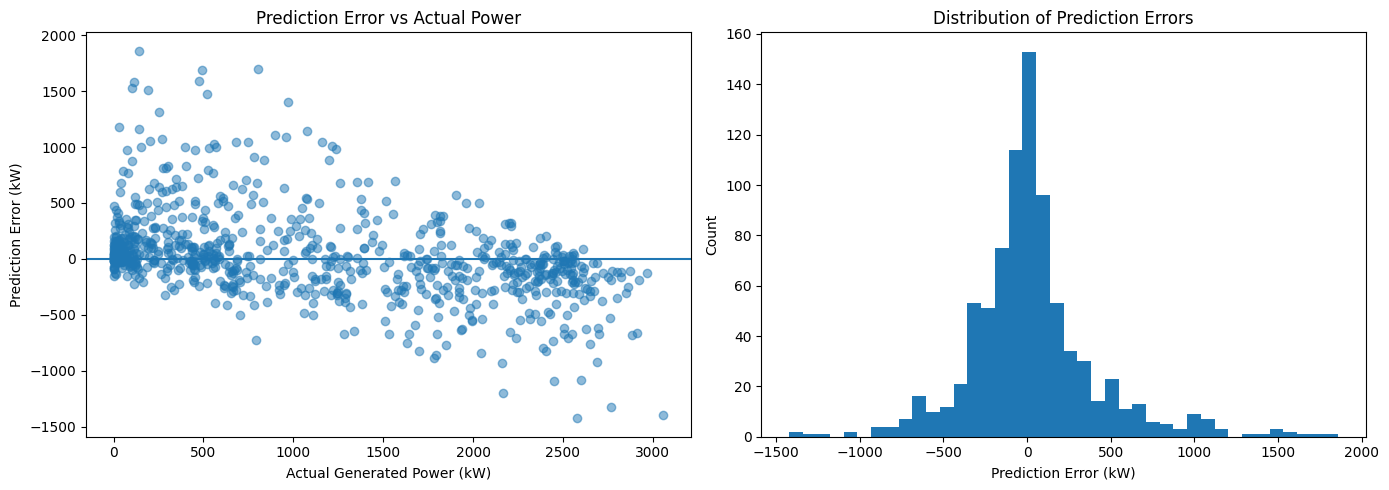

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(error_df["actual_power"], error_df["error"], alpha=0.5)
axes[0].axhline(0)
axes[0].set_xlabel("Actual Generated Power (kW)")
axes[0].set_ylabel("Prediction Error (kW)")
axes[0].set_title("Prediction Error vs Actual Power")

axes[1].hist(error_df["error"], bins=40)
axes[1].set_xlabel("Prediction Error (kW)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Prediction Errors")

plt.tight_layout()
plt.show()

The residual plot shows that most prediction errors are centered around zero, which agrees with the small mean error. This means the final model is reasonably balanced overall and does not consistently overpredict or underpredict. However, the residuals are still spread out for some observations, especially at higher actual power values. The histogram also shows that most errors are relatively small, but there are some large positive and negative errors. These larger errors may come from harder environmental conditions where similar feature values can still produce different solar outputs.

,count,mean,median,max
generation_level,,,,
High,278,261.775552,174.691886,1423.658371
Low,278,209.730621,104.772855,1860.293615
Medium,287,296.863665,210.512395,1697.682374


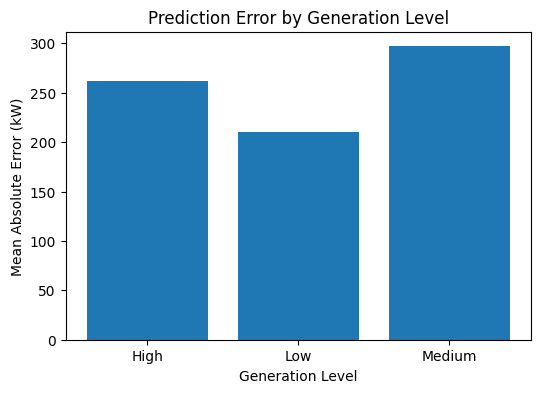

In [50]:
low_cut = error_df["actual_power"].quantile(0.33)
high_cut = error_df["actual_power"].quantile(0.67)

def generation_level(power):
    if power <= low_cut:
        return "Low"
    elif power <= high_cut:
        return "Medium"
    else:
        return "High"

error_df["generation_level"] = error_df["actual_power"].apply(generation_level)
level_error = error_df.groupby("generation_level")["absolute_error"].agg(
    ["count", "mean", "median", "max"]
)
display(level_error)

plt.figure(figsize=(6, 4))
plt.bar(level_error.index, level_error["mean"])
plt.xlabel("Generation Level")
plt.ylabel("Mean Absolute Error (kW)")
plt.title("Prediction Error by Generation Level")
plt.show()

We also compare errors across low, medium, and high generation levels which are defined using the 33rd and 67th percentiles of actual generated power. The results show that the medium generation group has the largest mean absolute error while the low generation group has the smallest mean absolute error. This suggests that low output cases are easier for the model to predict on average. Medium generation cases may be harder because they can occur under more mixed environmental conditions, such as partial cloud cover or changing solar geometry.

,count,mean,median,max
radiation_level,,,,
Low Radiation,281,189.283804,125.768096,984.906108
Medium Radiation,281,302.388343,202.618140,1697.682374
High Radiation,281,278.002543,148.246526,1860.293615


,count,mean,median,max
cloud_level,,,,
Low Cloud Cover,563,237.269380,130.504021,1860.293615
High Cloud Cover,280,295.342596,201.594750,1423.658371


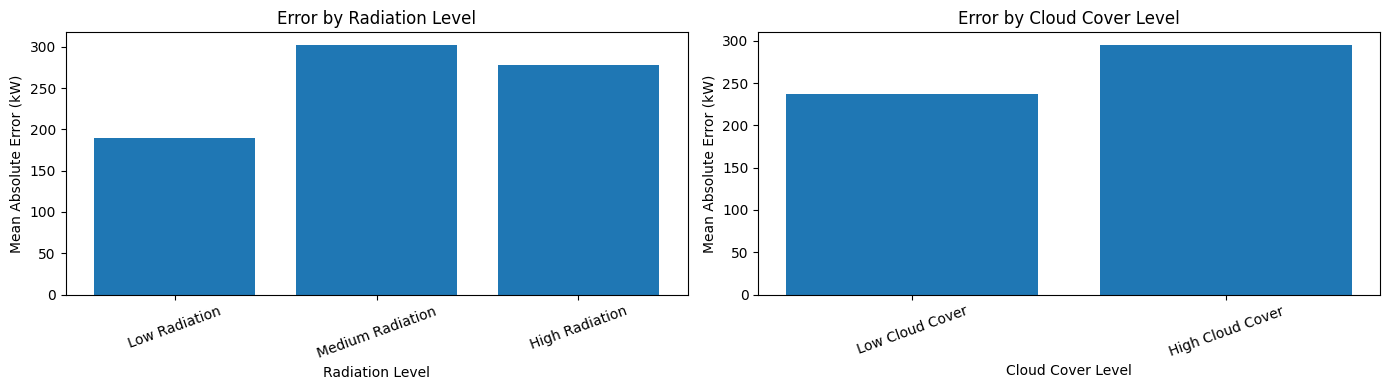

In [51]:
radiation_col = "shortwave_radiation_backwards_sfc"
cloud_col = "total_cloud_cover_sfc"

error_df["radiation_level"] = pd.qcut(
    error_df[radiation_col],
    q=3,
    labels=["Low Radiation", "Medium Radiation", "High Radiation"]
)

cloud_bins = pd.qcut(
    error_df[cloud_col],
    q=3,
    duplicates="drop"
)

num_cloud_bins = cloud_bins.cat.categories.size

if num_cloud_bins == 2:
    cloud_labels = ["Low Cloud Cover", "High Cloud Cover"]
elif num_cloud_bins == 3:
    cloud_labels = ["Low Cloud Cover", "Medium Cloud Cover", "High Cloud Cover"]
else:
    cloud_labels = [f"Cloud Group {i+1}" for i in range(num_cloud_bins)]

error_df["cloud_level"] = pd.qcut(
    error_df[cloud_col],
    q=3,
    labels=cloud_labels,
    duplicates="drop"
)

radiation_error = error_df.groupby("radiation_level", observed=True)["absolute_error"].agg(
    ["count", "mean", "median", "max"]
)

cloud_error = error_df.groupby("cloud_level", observed=True)["absolute_error"].agg(
    ["count", "mean", "median", "max"]
)

display(radiation_error)
display(cloud_error)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(radiation_error.index.astype(str), radiation_error["mean"])
axes[0].set_xlabel("Radiation Level")
axes[0].set_ylabel("Mean Absolute Error (kW)")
axes[0].set_title("Error by Radiation Level")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(cloud_error.index.astype(str), cloud_error["mean"])
axes[1].set_xlabel("Cloud Cover Level")
axes[1].set_ylabel("Mean Absolute Error (kW)")
axes[1].set_title("Error by Cloud Cover Level")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

Finally, we analyze model error under different radiation and cloud cover conditions. Shortwave radiation is divided into low, medium, and high groups using quantiles. For cloud cover, duplicate quantile edges occur because many samples have zero cloud cover, so the data is split into two available groups after dropping duplicate bins.

The radiation based results show that the low radiation group has the smallest mean absolute error while the medium radiation group has the largest error. This is similar to the generation level result: the middle range is harder to predict than very low output conditions. For cloud cover, the high cloud cover group has a larger mean absolute error than the the other group. This is physically reasonable because cloud cover can make solar generation more variable and harder to estimate. Overall, the error analysis shows that the final model performs best in clearer low radiation or low output conditions, while mixed radiation and cloudy conditions are more difficult.

# Part 7: Simple Solar Generation Prediction System

In [52]:
low_threshold = solar[target].quantile(0.33)
high_threshold = solar[target].quantile(0.67)

def classify_generation_level(predicted_power):
    if predicted_power <= low_threshold:
        return "Low Generation"
    elif predicted_power <= high_threshold:
        return "Medium Generation"
    else:
        return "High Generation"


def preprocess_single_input(input_df):
    processed = input_df.copy()
    angle_cols = [
        "wind_direction_10_m_above_gnd",
        "wind_direction_80_m_above_gnd",
        "wind_direction_900_mb",
        "azimuth"
    ]
    
    for col in angle_cols:
        radians = np.deg2rad(processed[col])
        processed[col + "_sin"] = np.sin(radians)
        processed[col + "_cos"] = np.cos(radians)
    
    processed = processed.drop(columns=angle_cols)
    processed = processed[X_train.columns]
    return processed


def predict_solar_generation(input_df):
    processed_input = preprocess_single_input(input_df)
    predicted_power = final_model.predict(processed_input)[0]
    generation_level = classify_generation_level(predicted_power)
    return predicted_power, generation_level

After selecting the final Gradient Boosting model, we build a simple prediction system. The goal is to let a user provide one set of meteorological and solar position features and receive a predicted solar power output. The system first applies the same preprocessing steps used during model training. In particular, directional variables such as wind direction and azimuth are converted into sine and cosine features. Then the processed input is passed into the final Gradient Boosting model. The system also converts the numerical prediction into a simple generation level. We define low, medium, and high generation using the 33rd and 67th percentiles of the original target variable:

$$
\text{Low: } \hat{y} \leq Q_{0.33}
$$

$$
\text{Medium: } Q_{0.33} < \hat{y} \leq Q_{0.67}
$$

$$
\text{High: } \hat{y} > Q_{0.67}
$$

This step makes the model output easier to interpret. Instead of only giving a numerical power value, the system also tells whether the predicted generation is low, medium, or high compared with the dataset distribution.

In [53]:
demo_indices = (
    error_df.sort_values("absolute_error")
    .groupby("generation_level", observed=True)
    .head(1)
    .index
)

demo_inputs = solar.drop(columns=[target]).loc[demo_indices]
demo_actual = solar[target].loc[demo_indices]
demo_results = []

for idx in demo_indices:
    input_row = solar.drop(columns=[target]).loc[[idx]]
    actual_power = solar[target].loc[idx]
    predicted_power, generation_level = predict_solar_generation(input_row)
    
    demo_results.append({
        "Index": idx,
        "Actual Power": actual_power,
        "Predicted Power": predicted_power,
        "Predicted Level": generation_level,
        "Error": predicted_power - actual_power,
        "Absolute Error": abs(predicted_power - actual_power)
    })

demo_results = pd.DataFrame(demo_results)
display(demo_results)

,Index,Actual Power,Predicted Power,Predicted Level,Error,Absolute Error
0,1498,5.555303,5.511598,Low Generation,-0.043705,0.043705
1,1650,1178.490000,1178.956124,Medium Generation,0.466124,0.466124
2,1666,2293.731600,2294.214324,High Generation,0.482724,0.482724


We test the prediction system using representative examples from the testing set. To show that the system works across different output ranges, we select one low generation case, one medium generation case and one high generation case. In these examples, the predicted values are very close to the actual values for all three generation levels. This shows that the final Gradient Boosting model can produce accurate predictions when the input conditions are similar to well-learned patterns in the training data. This demonstration should be interpreted together with the full error analysis from section 6. The selected examples show how the prediction system works, but they do not mean that every prediction will have such a small error. The full testing results still show that some environmental conditions are harder to predict.